# Data Understanding - Pharmacy & Doctor Database
## Avatar Project - TDSP Methodology

**Dataset #3:** Pharmacy & Doctor Database

**Intérêt:** Essentiel pour DSO 2 (adaptation audience), DSO 3 (CRM analytics), et DSO 4 (optimisation tournées avec données géospatiales)

---
## 1. Load Data

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('pharmacy_doctor_database.csv', encoding='utf-8-sig')

print(f"Dataset loaded: {df.shape[0]} clients, {df.shape[1]} columns")

Dataset loaded: 230 clients, 17 columns


---
## 2. First Look at Data

In [9]:
# Show first 5 rows
df.head()

,client_id,client_type,client_name,owner_name,specialty_type,address,governorate,delegation,latitude,longitude,phone,patients_per_month,last_visit_date,total_visits,engagement_level,preferred_products,languages
0,CLI0158,Cabinet Médical,Pr. Mohamed Elloumi,Pr. Mohamed Elloumi,Pédiatrie,"Centre Médical, 131 Rue de la République, Etta...",Ariana,Ettadhamen,36.849569,10.159108,+216 96 172 640,205,2025-12-06,17,Moyen,"LV Fersang junior, Vitonic Tonus",Arabe
1,CLI0194,Cabinet Médical,Dr. Sonia Farhat,Dr. Sonia Farhat,Gastro-entérologie,"Centre Médical, 115 Rue de la République, Sidi...",Ariana,Sidi Thabet,36.892104,10.194916,+216 31 391 128,714,2025-11-08,13,Faible,LV Fersang Gélule,Français
2,CLI0207,Cabinet Médical,Dr. Karim Belhadj,Dr. Karim Belhadj,Urologie,"Cabinet Médical, 128 Rue de la République, Kal...",Ariana,Kalâat el-Andalous,36.821800,10.255592,+216 90 608 312,685,2025-12-16,13,Moyen,"LV Sélénium A, C, E Anti-âge, PHYTOFANE Lotion...","Français, Arabe"
3,CLI0212,Cabinet Médical,Pr. Mohamed Jemni,Pr. Mohamed Jemni,Urologie,"Centre Médical, 148 Rue Ibn Khaldoun, Mnihla, ...",Ariana,Mnihla,36.813002,10.295579,+216 51 593 454,496,2025-09-26,18,Faible,"Echinacée, Zinc, Vit.C, TC 2000 Nutractiva, LV...",Arabe
4,CLI0216,Cabinet Médical,Dr. Mohamed Farhat,Dr. Mohamed Farhat,Ophtalmologie,"Centre Médical, 75 Avenue Mohamed V, Ariana Vi...",Ariana,Ariana Ville,36.804397,10.240419,+216 33 360 725,196,2025-12-25,17,Moyen,LV Fersang Gélule,Arabe


In [11]:
# Show dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   client_id           230 non-null    object 
 1   client_type         230 non-null    object 
 2   client_name         230 non-null    object 
 3   owner_name          230 non-null    object 
 4   specialty_type      230 non-null    object 
 5   address             230 non-null    object 
 6   governorate         230 non-null    object 
 7   delegation          230 non-null    object 
 8   latitude            230 non-null    float64
 9   longitude           230 non-null    float64
 10  phone               230 non-null    object 
 11  patients_per_month  230 non-null    int64  
 12  last_visit_date     230 non-null    object 
 13  total_visits        230 non-null    int64  
 14  engagement_level    230 non-null    object 
 15  preferred_products  230 non-null    object 
 16  language

In [13]:
# Show column names
print("Columns:")
for col in df.columns:
    print(f"  - {col}")

Columns:
  - client_id
  - client_type
  - client_name
  - owner_name
  - specialty_type
  - address
  - governorate
  - delegation
  - latitude
  - longitude
  - phone
  - patients_per_month
  - last_visit_date
  - total_visits
  - engagement_level
  - preferred_products
  - languages


### Column Descriptions:

| Column | Description |
|--------|-------------|
| **client_id** | Unique client identifier |
| **client_type** | Type: Pharmacie or Cabinet Médical |
| **client_name** | Name of pharmacy or doctor |
| **owner_name** | Owner/proprietor name |
| **specialty_type** | Pharmacy type or medical specialty |
| **address** | Full address |
| **governorate** | Governorate (region) |
| **delegation** | Delegation (sub-region) |
| **latitude** | GPS latitude coordinate |
| **longitude** | GPS longitude coordinate |
| **phone** | Contact phone number |
| **patients_per_month** | Average patients served per month |
| **last_visit_date** | Date of last rep visit |
| **total_visits** | Total number of rep visits |
| **engagement_level** | Engagement level (Élevé/Moyen/Faible) |
| **preferred_products** | Products the client prefers |
| **languages** | Languages spoken |

---
## 3. Check Data Quality

In [17]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(1))

Missing Values:
client_id             0
client_type           0
client_name           0
owner_name            0
specialty_type        0
address               0
governorate           0
delegation            0
latitude              0
longitude             0
phone                 0
patients_per_month    0
last_visit_date       0
total_visits          0
engagement_level      0
preferred_products    0
languages             0
dtype: int64

Missing percentage:
client_id             0.0
client_type           0.0
client_name           0.0
owner_name            0.0
specialty_type        0.0
address               0.0
governorate           0.0
delegation            0.0
latitude              0.0
longitude             0.0
phone                 0.0
patients_per_month    0.0
last_visit_date       0.0
total_visits          0.0
engagement_level      0.0
preferred_products    0.0
languages             0.0
dtype: float64


In [19]:
# Check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate client IDs: {df['client_id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate client IDs: 0


---
## 4. Analyze Client Types

In [22]:
# Client type distribution
print("Client Types:")
print(df['client_type'].value_counts())
print(f"\nPercentages:")
print((df['client_type'].value_counts() / len(df) * 100).round(1))

Client Types:
client_type
Pharmacie          150
Cabinet Médical     80
Name: count, dtype: int64

Percentages:
client_type
Pharmacie          65.2
Cabinet Médical    34.8
Name: count, dtype: float64


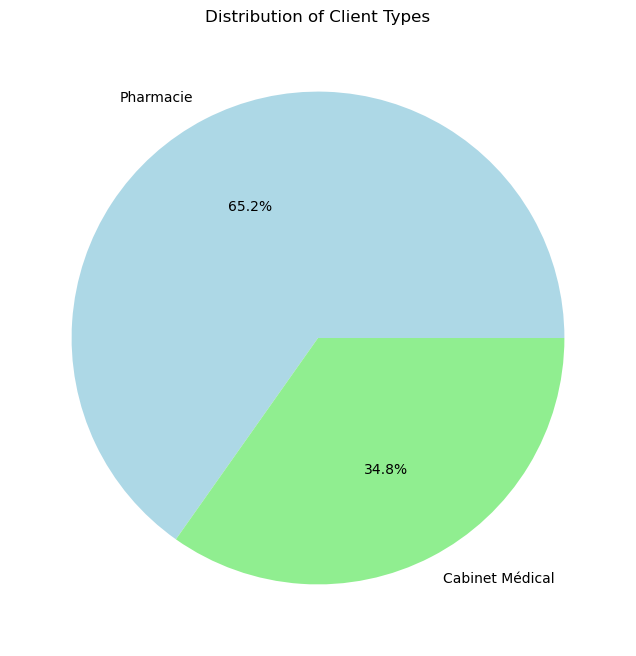

In [24]:
# Visualize client types
df['client_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8,8), colors=['lightblue', 'lightgreen'])
plt.title('Distribution of Client Types')
plt.ylabel('')
plt.show()

---
## 5. Analyze Specialties

In [27]:
# Pharmacy types
pharmacies = df[df['client_type'] == 'Pharmacie']
print("Pharmacy Types:")
print(pharmacies['specialty_type'].value_counts())

Pharmacy Types:
specialty_type
Pharmacie Générale       45
Pharmacie de Nuit        40
Parapharmacie            36
Pharmacie de Quartier    29
Name: count, dtype: int64


In [29]:
# Medical specialties
doctors = df[df['client_type'] == 'Cabinet Médical']
print("\nMedical Specialties:")
print(doctors['specialty_type'].value_counts())


Medical Specialties:
specialty_type
Pneumologie           11
Gastro-entérologie     8
Ophtalmologie          7
ORL                    7
Gynécologie            7
Pédiatrie              6
Dermatologie           6
Médecine Générale      5
Cardiologie            5
Neurologie             5
Rhumatologie           4
Urologie               3
Psychiatrie            3
Endocrinologie         3
Name: count, dtype: int64


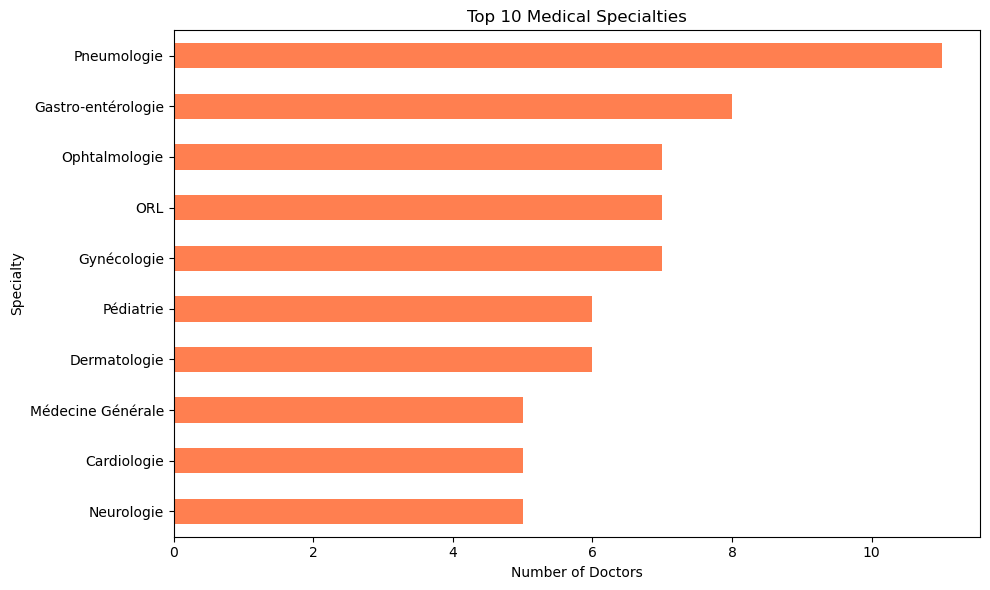

In [31]:
# Visualize top medical specialties
doctors['specialty_type'].value_counts().head(10).plot(kind='barh', color='coral', figsize=(10,6))
plt.title('Top 10 Medical Specialties')
plt.xlabel('Number of Doctors')
plt.ylabel('Specialty')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6. Analyze Geographic Distribution

In [34]:
# Clients by governorate
print("Clients by Governorate:")
print(df['governorate'].value_counts())

Clients by Governorate:
governorate
Sfax         27
Bizerte      26
Tunis        26
Sousse       25
Ben Arous    24
Manouba      24
Ariana       21
Monastir     21
Nabeul       19
Gabès        17
Name: count, dtype: int64


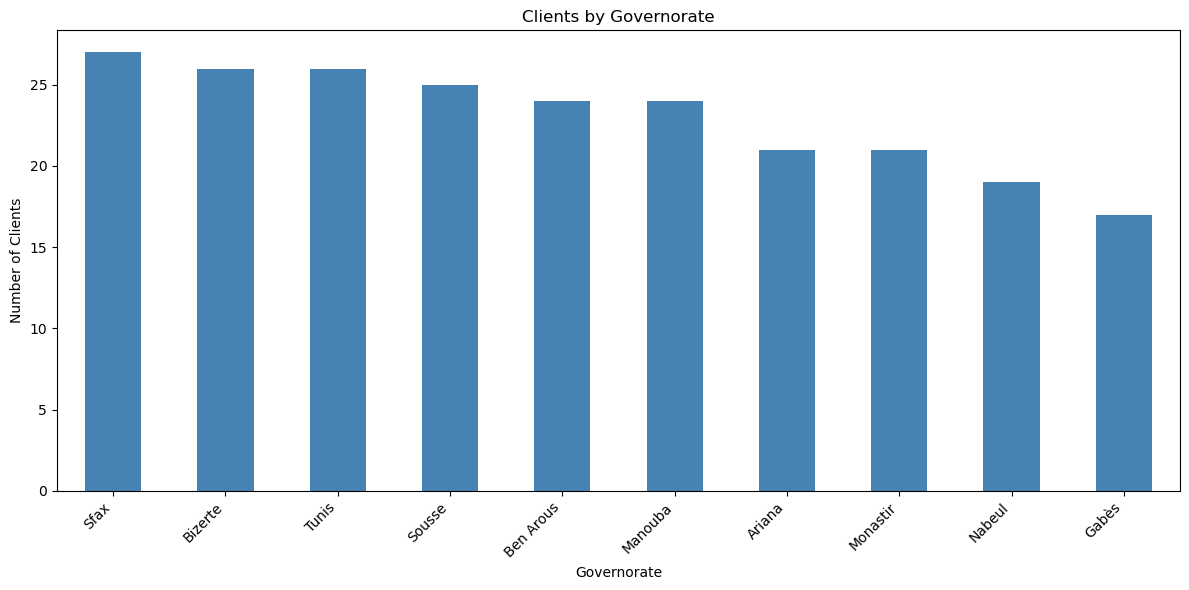

In [36]:
# Visualize geographic distribution
df['governorate'].value_counts().plot(kind='bar', color='steelblue', figsize=(12,6))
plt.title('Clients by Governorate')
plt.xlabel('Governorate')
plt.ylabel('Number of Clients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
# Number of unique delegations
print(f"\nTotal unique delegations: {df['delegation'].nunique()}")
print(f"\nTop 10 delegations with most clients:")
print(df['delegation'].value_counts().head(10))


Total unique delegations: 104

Top 10 delegations with most clients:
delegation
Mornaguia        8
El Amra          5
Ettadhamen       4
Kalâa Seghira    4
Ghannouch        4
Bizerte Nord     4
Mégrine          4
Ben Arous        4
Borj El Amri     4
Zéramdine        4
Name: count, dtype: int64


In [40]:
# GPS coordinates check
print("\nGPS Coordinates Range:")
print(f"Latitude: {df['latitude'].min():.6f} to {df['latitude'].max():.6f}")
print(f"Longitude: {df['longitude'].min():.6f} to {df['longitude'].max():.6f}")


GPS Coordinates Range:
Latitude: 33.800513 to 37.299311
Longitude: 9.712358 to 10.796737


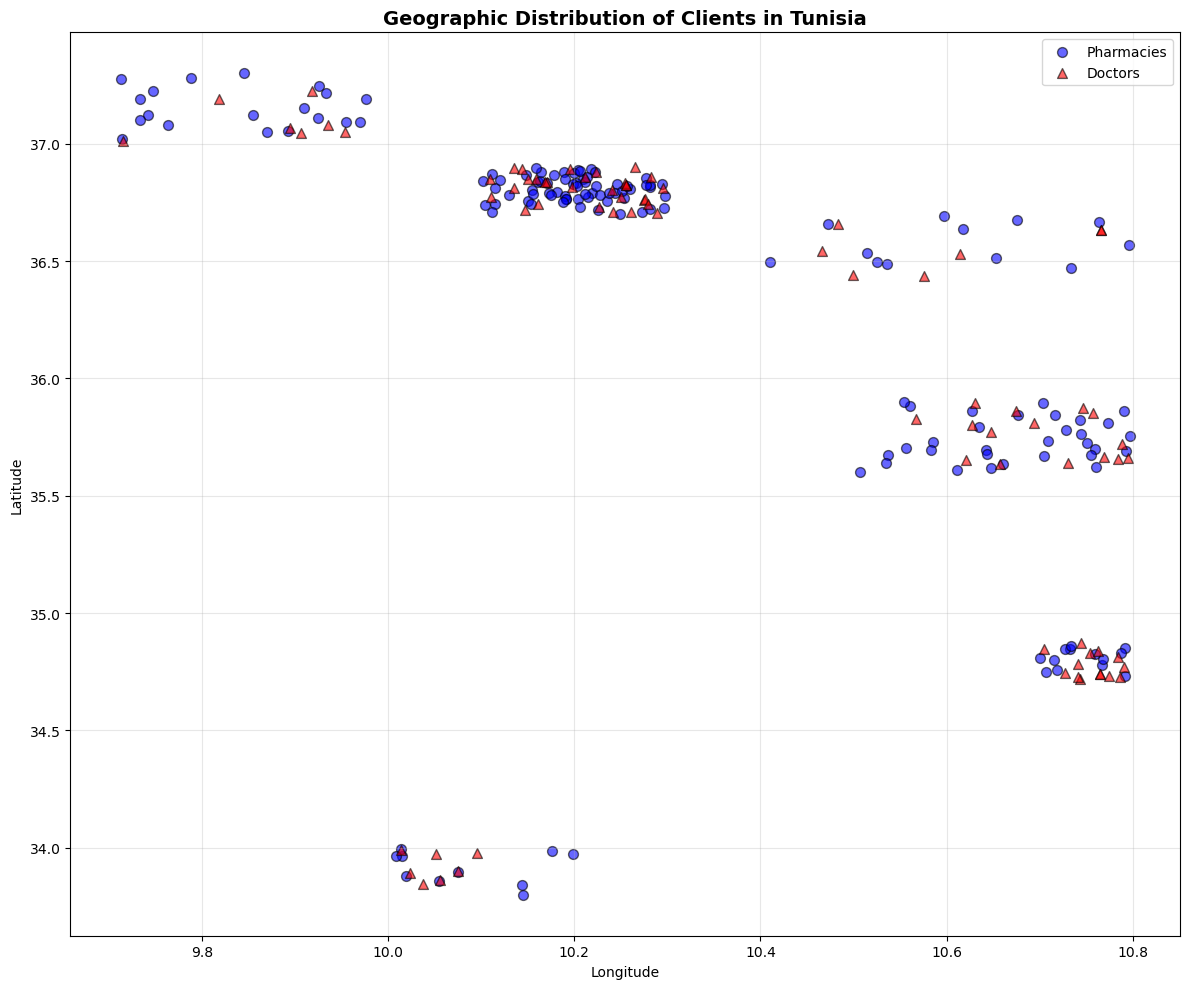

In [42]:
# Visualize geographic spread (scatter plot)
plt.figure(figsize=(12, 10))
pharmacies_plot = df[df['client_type'] == 'Pharmacie']
doctors_plot = df[df['client_type'] == 'Cabinet Médical']

plt.scatter(pharmacies_plot['longitude'], pharmacies_plot['latitude'], 
           alpha=0.6, s=50, c='blue', label='Pharmacies', edgecolors='black')
plt.scatter(doctors_plot['longitude'], doctors_plot['latitude'], 
           alpha=0.6, s=50, c='red', label='Doctors', marker='^', edgecolors='black')

plt.title('Geographic Distribution of Clients in Tunisia', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Analyze Patient Volume

In [45]:
# Patient volume statistics
print("Patients per Month - Overall Statistics:")
print(df['patients_per_month'].describe())

Patients per Month - Overall Statistics:
count     230.000000
mean     1570.317391
std       995.278333
min       155.000000
25%       649.250000
50%      1461.500000
75%      2407.250000
max      3493.000000
Name: patients_per_month, dtype: float64


In [47]:
# Compare pharmacies vs doctors
print("\nPatients per Month by Client Type:")
print(f"\nPharmacies:")
print(pharmacies['patients_per_month'].describe())
print(f"\nDoctors:")
print(doctors['patients_per_month'].describe())


Patients per Month by Client Type:

Pharmacies:
count     150.000000
mean     2144.233333
std       740.708217
min       821.000000
25%      1525.500000
50%      2172.000000
75%      2709.750000
max      3493.000000
Name: patients_per_month, dtype: float64

Doctors:
count     80.000000
mean     494.225000
std      196.456519
min      155.000000
25%      304.750000
50%      508.000000
75%      677.000000
max      798.000000
Name: patients_per_month, dtype: float64


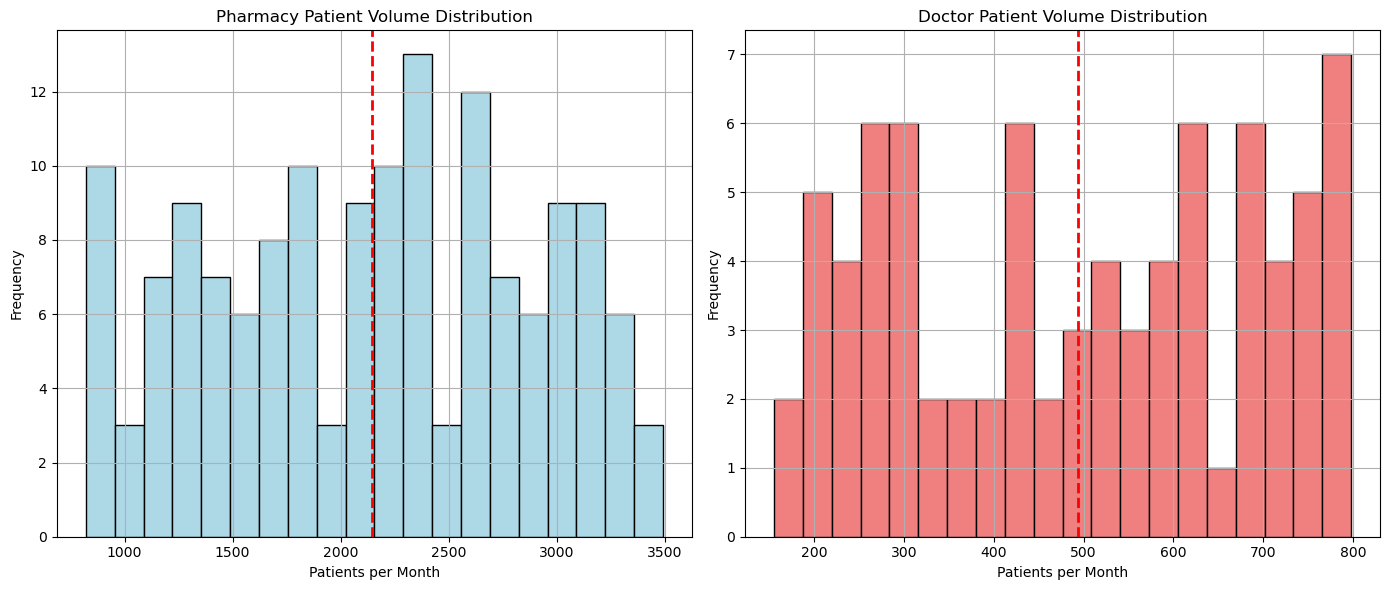

In [49]:
# Visualize patient volume distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pharmacies
pharmacies['patients_per_month'].hist(bins=20, color='lightblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Pharmacy Patient Volume Distribution')
axes[0].set_xlabel('Patients per Month')
axes[0].set_ylabel('Frequency')
axes[0].axvline(pharmacies['patients_per_month'].mean(), color='red', linestyle='--', linewidth=2)

# Doctors
doctors['patients_per_month'].hist(bins=20, color='lightcoral', edgecolor='black', ax=axes[1])
axes[1].set_title('Doctor Patient Volume Distribution')
axes[1].set_xlabel('Patients per Month')
axes[1].set_ylabel('Frequency')
axes[1].axvline(doctors['patients_per_month'].mean(), color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

---
## 8. Analyze Engagement Levels

In [52]:
# Engagement distribution
print("Engagement Levels:")
print(df['engagement_level'].value_counts())
print(f"\nPercentages:")
print((df['engagement_level'].value_counts() / len(df) * 100).round(1))

Engagement Levels:
engagement_level
Faible    163
Moyen      45
Élevé      22
Name: count, dtype: int64

Percentages:
engagement_level
Faible    70.9
Moyen     19.6
Élevé      9.6
Name: count, dtype: float64


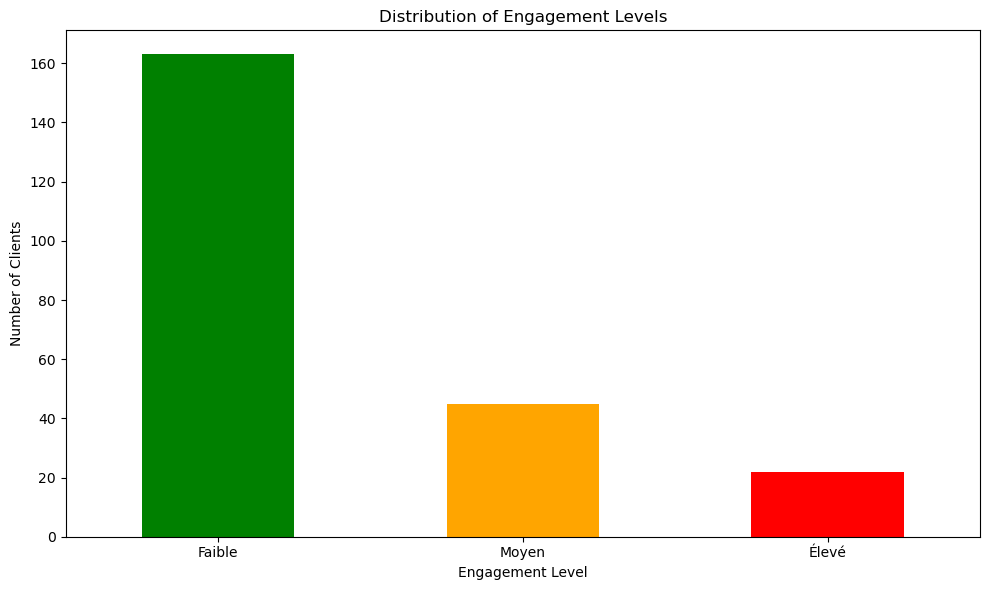

In [54]:
# Visualize engagement levels
df['engagement_level'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'], figsize=(10,6))
plt.title('Distribution of Engagement Levels')
plt.xlabel('Engagement Level')
plt.ylabel('Number of Clients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
# Engagement by client type
print("\nEngagement by Client Type:")
engagement_by_type = pd.crosstab(df['client_type'], df['engagement_level'])
print(engagement_by_type)


Engagement by Client Type:
engagement_level  Faible  Moyen  Élevé
client_type                           
Cabinet Médical       48     21     11
Pharmacie            115     24     11


In [58]:
# Low engagement clients (priority for route optimization - DSO 4)
low_engagement = df[df['engagement_level'] == 'Faible']
print(f"\n Low Engagement Clients: {len(low_engagement)} ({len(low_engagement)/len(df)*100:.1f}%)")
print(f"   - These are priority targets for DSO 4 (Route Optimization)")


 Low Engagement Clients: 163 (70.9%)
   - These are priority targets for DSO 4 (Route Optimization)


---
## 9. Analyze Visit Patterns

In [61]:
# Total visits statistics
print("Total Visits Statistics:")
print(df['total_visits'].describe())

Total Visits Statistics:
count    230.000000
mean      12.608696
std        6.550703
min        2.000000
25%        7.000000
50%       12.000000
75%       18.000000
max       25.000000
Name: total_visits, dtype: float64


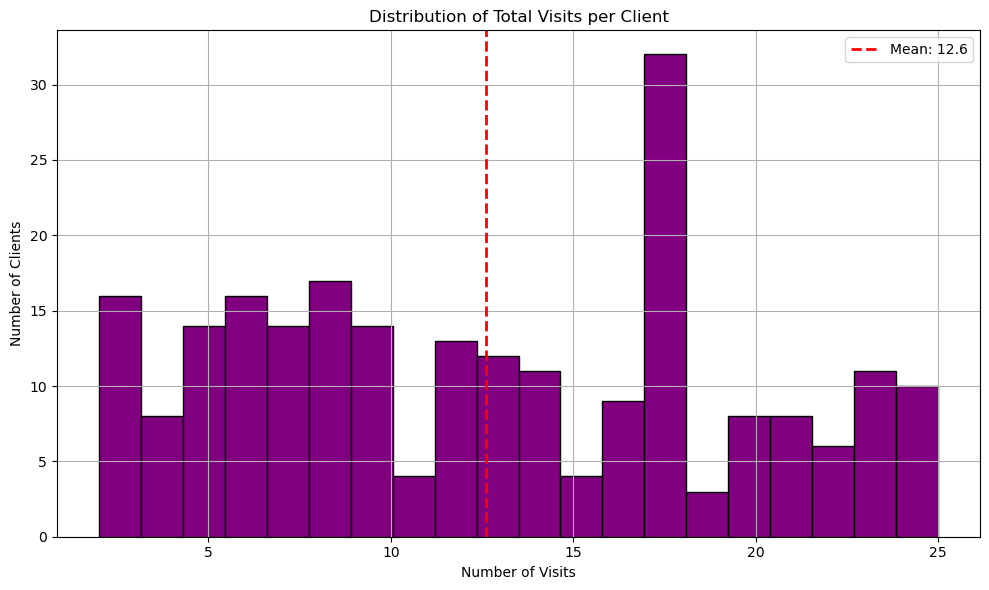

In [63]:
# Distribution of total visits
df['total_visits'].hist(bins=20, color='purple', edgecolor='black', figsize=(10,6))
plt.title('Distribution of Total Visits per Client')
plt.xlabel('Number of Visits')
plt.ylabel('Number of Clients')
plt.axvline(df['total_visits'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["total_visits"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
# Last visit analysis
df['last_visit_date'] = pd.to_datetime(df['last_visit_date'])
df['days_since_last_visit'] = (pd.Timestamp.now() - df['last_visit_date']).dt.days

print("\nDays Since Last Visit:")
print(df['days_since_last_visit'].describe())


Days Since Last Visit:
count    230.000000
mean      96.839130
std       52.458719
min       11.000000
25%       52.250000
50%       89.500000
75%      143.000000
max      203.000000
Name: days_since_last_visit, dtype: float64


In [67]:
# Clients not visited recently (>90 days)
not_visited_recently = df[df['days_since_last_visit'] > 90]
print(f"\n Clients not visited in >90 days: {len(not_visited_recently)} ({len(not_visited_recently)/len(df)*100:.1f}%)")
print(f"   - Priority for re-engagement!")


 Clients not visited in >90 days: 113 (49.1%)
   - Priority for re-engagement!


---
## 10. Analyze Languages

In [70]:
# Language preferences
print("Language Combinations:")
print(df['languages'].value_counts())

Language Combinations:
languages
Français                             53
Arabe                                52
Français, Arabe, Anglais, Italien    51
Français, Arabe, Anglais             40
Français, Arabe                      34
Name: count, dtype: int64


In [72]:
# Count individual languages
all_languages = []
for langs in df['languages']:
    for lang in langs.split(', '):
        all_languages.append(lang.strip())

from collections import Counter
language_counts = Counter(all_languages)

print("\nIndividual Language Counts:")
for lang, count in language_counts.most_common():
    print(f"  {lang}: {count} ({count/len(df)*100:.1f}%)")


Individual Language Counts:
  Français: 178 (77.4%)
  Arabe: 177 (77.0%)
  Anglais: 91 (39.6%)
  Italien: 51 (22.2%)


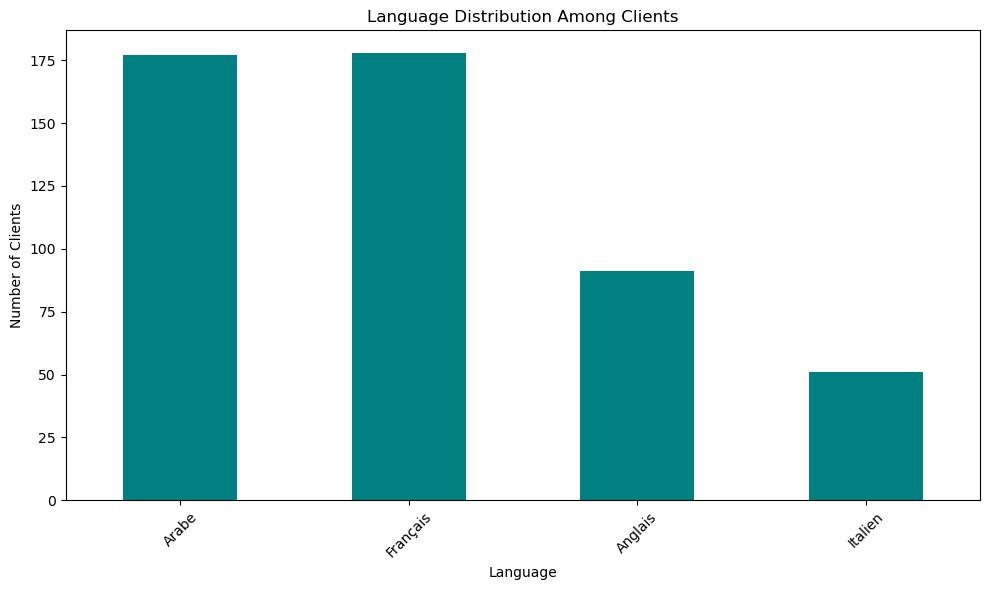

In [74]:
# Visualize languages
lang_df = pd.DataFrame.from_dict(language_counts, orient='index', columns=['Count'])
lang_df.plot(kind='bar', color='teal', legend=False, figsize=(10,6))
plt.title('Language Distribution Among Clients')
plt.xlabel('Language')
plt.ylabel('Number of Clients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 11. Analyze Preferred Products

In [77]:
# Extract all preferred products
all_products = []
for prods in df['preferred_products']:
    products = prods.split(', ')
    for prod in products:
        all_products.append(prod.strip())

product_counts = Counter(all_products)

print("Top 10 Preferred Products:")
for prod, count in product_counts.most_common(10):
    print(f"  {prod}: {count}")

Top 10 Preferred Products:
  Echinacée: 46
  Zinc: 46
  Vit.C: 46
  LV Fersang junior: 44
  OLIGOVIT Trio: 42
  LV Sélénium A: 35
  C: 35
  E Anti-âge: 35
  PédiaKids Gelée royale: 32
  LV Vitamine A: 31


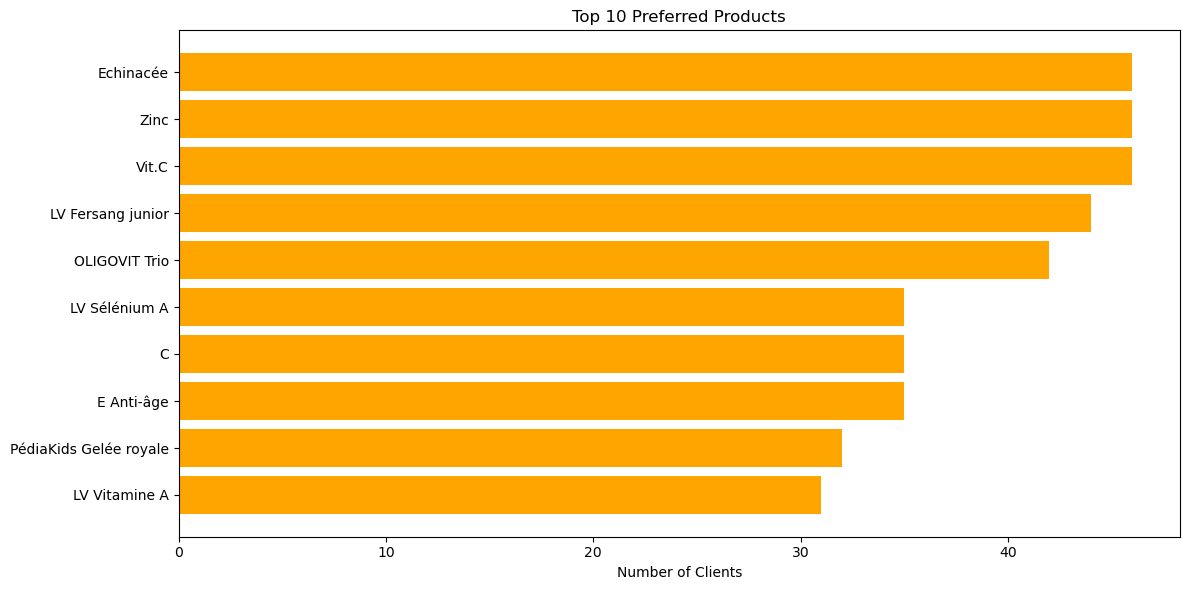

In [79]:
# Visualize top products
top_products = dict(product_counts.most_common(10))
plt.figure(figsize=(12,6))
plt.barh(list(top_products.keys()), list(top_products.values()), color='orange')
plt.xlabel('Number of Clients')
plt.title('Top 10 Preferred Products')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 12. Priority Targets for Route Optimization (DSO 4)

In [82]:
# Identify low-engagement clients with low patient volume (quick wins)
# These are ideal for route optimization

# Create priority score: lower patient volume + low engagement = higher priority
df['priority_score'] = 0

# Points for low engagement
df.loc[df['engagement_level'] == 'Faible', 'priority_score'] += 3
df.loc[df['engagement_level'] == 'Moyen', 'priority_score'] += 1

# Points for low patient volume (easier to visit quickly)
median_patients = df['patients_per_month'].median()
df.loc[df['patients_per_month'] < median_patients, 'priority_score'] += 2

# Points for not visited recently
df.loc[df['days_since_last_visit'] > 90, 'priority_score'] += 2

print("Top 20 Priority Targets for Route Optimization:")
priority_targets = df.nlargest(20, 'priority_score')[['client_id', 'client_name', 'client_type', 
                                                         'governorate', 'delegation', 'patients_per_month', 
                                                         'engagement_level', 'days_since_last_visit', 'priority_score']]
print(priority_targets.to_string(index=False))

Top 20 Priority Targets for Route Optimization:
client_id               client_name     client_type governorate      delegation  patients_per_month engagement_level  days_since_last_visit  priority_score
  CLI0194          Dr. Sonia Farhat Cabinet Médical      Ariana     Sidi Thabet                 714           Faible                    105               7
  CLI0212         Pr. Mohamed Jemni Cabinet Médical      Ariana          Mnihla                 496           Faible                    148               7
  CLI0026 Para-Pharmacie du Progrès       Pharmacie      Ariana          Raoued                1236           Faible                    119               7
  CLI0151          Dr. Fatma Farhat Cabinet Médical   Ben Arous      Hammam Lif                 792           Faible                    122               7
  CLI0156        Dr. Sonia Ghariani Cabinet Médical   Ben Arous         Mégrine                 290           Faible                    113               7
  CLI0162       

In [84]:
# Priority by governorate
print("\nHigh Priority Clients by Governorate:")
high_priority = df[df['priority_score'] >= 5]
print(high_priority['governorate'].value_counts())


High Priority Clients by Governorate:
governorate
Sfax         17
Sousse       16
Manouba      15
Gabès        14
Nabeul       14
Ariana       12
Ben Arous    12
Bizerte      12
Tunis        12
Monastir     10
Name: count, dtype: int64


---
## 13. Summary Statistics

In [87]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total clients: {len(df)}")
print(f"  - Pharmacies: {(df['client_type'] == 'Pharmacie').sum()}")
print(f"  - Doctors: {(df['client_type'] == 'Cabinet Médical').sum()}")
print(f"\nGeographic coverage:")
print(f"  - Governorates: {df['governorate'].nunique()}")
print(f"  - Delegations: {df['delegation'].nunique()}")
print(f"\nEngagement:")
print(f"  - High engagement: {(df['engagement_level'] == 'Élevé').sum()}")
print(f"  - Medium engagement: {(df['engagement_level'] == 'Moyen').sum()}")
print(f"  - Low engagement: {(df['engagement_level'] == 'Faible').sum()} ")
print(f"\nActivity:")
print(f"  - Average visits per client: {df['total_visits'].mean():.1f}")
print(f"  - Average days since last visit: {df['days_since_last_visit'].mean():.0f}")
print(f"  - Clients not visited in >90 days: {(df['days_since_last_visit'] > 90).sum()}")
print(f"\nPatient volume:")
print(f"  - Average patients/month: {df['patients_per_month'].mean():.0f}")
print(f"  - Total patients served: {df['patients_per_month'].sum():,}")
print(f"\nLanguages:")
print(f"  - Français: {len([l for l in all_languages if l == 'Français'])} clients")
print(f"  - Arabe: {len([l for l in all_languages if l == 'Arabe'])} clients")
print(f"  - Anglais: {len([l for l in all_languages if l == 'Anglais'])} clients")
print(f"\nData completeness: 100% (no missing values)")

DATASET SUMMARY
Total clients: 230
  - Pharmacies: 150
  - Doctors: 80

Geographic coverage:
  - Governorates: 10
  - Delegations: 104

Engagement:
  - High engagement: 22
  - Medium engagement: 45
  - Low engagement: 163 

Activity:
  - Average visits per client: 12.6
  - Average days since last visit: 97
  - Clients not visited in >90 days: 113

Patient volume:
  - Average patients/month: 1570
  - Total patients served: 361,173

Languages:
  - Français: 178 clients
  - Arabe: 177 clients
  - Anglais: 91 clients

Data completeness: 100% (no missing values)


---
## 14. Key Findings

### Main Observations:

**1. Client Portfolio:**
- 230 total clients (150 pharmacies, 80 doctors)
- Diverse medical specialties covered
- Mix of pharmacy types (general, neighborhood, night, parapharmacy)
- Full geographic coverage across Tunisia (10 governorates, 70+ delegations)

**2. Geographic Distribution:**
- GPS coordinates available for all clients (critical for DSO 4)
- Concentration in major cities (Tunis, Sfax, Sousse)
- Some rural areas with lower coverage
- Clear clustering patterns by region

**3. Engagement Patterns:**
- Significant portion of low-engagement clients (opportunity!)
- Average ~10 visits per client
- Many clients not visited in >90 days
- Clear correlation between visits and engagement level

**4. Patient Volume:**
- Pharmacies serve 800-3500 patients/month
- Doctors see 150-800 patients/month
- High-volume clients exist in all regions
- Patient volume varies significantly by location

**5. Language & Communication:**
- Most clients speak Français and/or Arabe
- Some trilingual (+ Anglais)
- Language adaptation critical for DSO 2

### Relevance to Avatar Project:

**For DSO 2 (Audience Adaptation):**
- Specialty data enables scientific depth adjustment
- Language preferences for multilingual presentations
- Client type (pharmacy vs doctor) for content targeting
- Product preferences for personalized recommendations

**For DSO 3 (CRM & Analytics):**
- Engagement levels for segmentation
- Visit history for pattern analysis
- Patient volume for client prioritization
- Product preferences for cross-selling insights

**For DSO 4 (Route Optimization) - MOST CRITICAL:**
- GPS coordinates for distance calculations
- Low-engagement clients identification (priority targets)
- Patient volume for visit duration estimation
- Geographic clustering for efficient routing
- Visit history to avoid over-visiting high-engagement clients

---
# Data Preparation Phase - Pharmacy & Doctor Database
## Avatar Project - TDSP Methodology

**Objectif :** Préparer le dataset `pharmacy_doctor_database.csv` pour alimenter les modules de présentation personnalisée, d'analytics CRM et d'optimisation de tournées de l'avatar.

| DSO | Utilisation de ce dataset |
|-----|---------------------------|
| **DSO 2** | Adaptation de l'audience — langue, type de client, spécialité médicale, produits préférés |
| **DSO 3** | CRM analytics — segmentation clients, engagement scoring, suivi portefeuille |
| **DSO 4** | Route Optimization — coordonnées GPS, clustering géographique, scoring de priorité de visite |

**Pipeline :**
1. Imports & reload
2. Typage & normalisation temporelle (last_visit_date)
3. Nettoyage & standardisation des catégories
4. Parsing des colonnes multi-valeurs (languages, preferred_products)
5. Validation & nettoyage des coordonnées GPS
6. Feature engineering (flags, scores, segmentation)
7. Géo-clustering pour optimisation de tournées (DSO 4)
8. Vues DSO-spécifiques & exports
9. Rapport qualité final


---
## 1. Imports & Data Reload

In [91]:
import pandas as pd
import numpy as np
import re
import json
import os
from math import radians, sin, cos, sqrt, atan2

# Reload fresh copy — phase auto-suffisante
df_raw = pd.read_csv('pharmacy_doctor_database.csv', encoding='utf-8-sig')
df = df_raw.copy()

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.dtypes)


Loaded: 230 rows × 17 columns
client_id              object
client_type            object
client_name            object
owner_name             object
specialty_type         object
address                object
governorate            object
delegation             object
latitude              float64
longitude             float64
phone                  object
patients_per_month      int64
last_visit_date        object
total_visits            int64
engagement_level       object
preferred_products     object
languages              object
dtype: object


---
## 2. Typage & Normalisation Temporelle

La colonne `last_visit_date` est stockée en `object`. On la convertit en datetime et on calcule les features de recency essentielles pour DSO 3 (CRM) et DSO 4 (priorisation visites).


In [94]:
# Date de référence = aujourd'hui (simulation à la date du dernier enregistrement)
reference_date = pd.Timestamp('2026-02-21')

# Conversion
df['last_visit_date'] = pd.to_datetime(df['last_visit_date'], errors='coerce')

# Features de recency
df['days_since_last_visit']   = (reference_date - df['last_visit_date']).dt.days
df['weeks_since_last_visit']  = (df['days_since_last_visit'] / 7).round(1)
df['months_since_last_visit'] = (df['days_since_last_visit'] / 30.44).round(1)
df['last_visit_month']        = df['last_visit_date'].dt.strftime('%Y-%m')

# Catégorie de recency
def recency_category(days):
    if pd.isna(days):
        return 'Inconnu'
    elif days <= 30:
        return 'Récent (≤30j)'
    elif days <= 60:
        return 'Normal (31-60j)'
    elif days <= 90:
        return 'À relancer (61-90j)'
    else:
        return 'Urgence (>90j)'

df['recency_category'] = df['days_since_last_visit'].apply(recency_category)

print("Features de recency ajoutées:")
print(df[['client_name','last_visit_date','days_since_last_visit','recency_category']].head(6).to_string(index=False))
print(f"\nDistribution recency:")
print(df['recency_category'].value_counts())
print(f"\nDates invalides: {df['last_visit_date'].isna().sum()}")


Features de recency ajoutées:
        client_name last_visit_date  days_since_last_visit    recency_category
Pr. Mohamed Elloumi      2025-12-06                     77 À relancer (61-90j)
   Dr. Sonia Farhat      2025-11-08                    105      Urgence (>90j)
  Dr. Karim Belhadj      2025-12-16                     67 À relancer (61-90j)
  Pr. Mohamed Jemni      2025-09-26                    148      Urgence (>90j)
 Dr. Mohamed Farhat      2025-12-25                     58     Normal (31-60j)
    Dr. Mehdi Jemni      2026-01-10                     42     Normal (31-60j)

Distribution recency:
recency_category
Urgence (>90j)         113
À relancer (61-90j)     47
Normal (31-60j)         45
Récent (≤30j)           25
Name: count, dtype: int64

Dates invalides: 0


---
## 3. Nettoyage & Standardisation des Catégories

Normalisation des colonnes catégorielles clés pour garantir des agrégations cohérentes.


In [97]:
# ── client_type ─────────────────────────────────────────────────────────
client_type_map = {
    r'pharmacie'       : 'Pharmacie',
    r'cabinet m[eé]d' : 'Cabinet Médical',
    r'clinique'        : 'Clinique',
    r'h[oô]pital'      : 'Hôpital',
    r'parapharm'       : 'Parapharmacie',
}

def normalize_client_type(val):
    v = str(val).strip()
    for pattern, replacement in client_type_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['client_type'] = df['client_type'].apply(normalize_client_type)
print("client_type:", df['client_type'].value_counts().to_dict())


client_type: {'Pharmacie': 150, 'Cabinet Médical': 80}


In [99]:
# ── engagement_level ────────────────────────────────────────────────────
engagement_map = {
    r'[eé]lev[eé]|fort|high'  : 'Élevé',
    r'moyen|medium|mod[eé]r'  : 'Moyen',
    r'faible|low|bas'          : 'Faible',
}

def normalize_engagement(val):
    v = str(val).strip()
    for pattern, replacement in engagement_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['engagement_level'] = df['engagement_level'].apply(normalize_engagement)

# Engagement numérique pour scoring
engagement_num = {'Faible': 1, 'Moyen': 2, 'Élevé': 3}
df['engagement_score_num'] = df['engagement_level'].map(engagement_num).fillna(1).astype(int)

print("engagement_level:", df['engagement_level'].value_counts().to_dict())


engagement_level: {'Faible': 163, 'Moyen': 45, 'Élevé': 22}


In [101]:
# ── governorate ─────────────────────────────────────────────────────────
gov_map = {
    'ben arous' : 'Ben Arous',
    'benarous'  : 'Ben Arous',
    'tunis'     : 'Tunis',
    'sfax'      : 'Sfax',
    'sousse'    : 'Sousse',
    'monastir'  : 'Monastir',
    'gab[eè]s'  : 'Gabès',
    'bizerte'   : 'Bizerte',
    'nabeul'    : 'Nabeul',
    'ariana'    : 'Ariana',
    'manouba'   : 'Manouba',
}

def normalize_gov(val):
    v = str(val).strip()
    for pattern, replacement in gov_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['governorate'] = df['governorate'].apply(normalize_gov)
df['delegation']  = df['delegation'].str.strip().str.title()

print("Gouvernorats:", df['governorate'].value_counts().to_dict())


Gouvernorats: {'Sfax': 27, 'Bizerte': 26, 'Tunis': 26, 'Sousse': 25, 'Ben Arous': 24, 'Manouba': 24, 'Ariana': 21, 'Monastir': 21, 'Nabeul': 19, 'Gabès': 17}


In [103]:
# ── specialty_type ─────────────────────────────────────────────────────
# Nettoyage strip + title
df['specialty_type'] = df['specialty_type'].str.strip()

# Regroupement des spécialités médicales en macro-catégories (utile DSO 2 & 3)
specialty_macro = {
    r'g[eé]n[eé]ral'                        : 'Médecine Générale',
    r'p[eé]diatr'                            : 'Pédiatrie',
    r'cardio'                                : 'Cardiologie',
    r'dermatol|peau'                         : 'Dermatologie',
    r'gastro|dig[eé]st'                      : 'Gastro-entérologie',
    r'gynéco|gyneco|obstétr'                 : 'Gynécologie',
    r'neurolog'                              : 'Neurologie',
    r'ophtalmol|ophthal'                     : 'Ophtalmologie',
    r'endocrin|diab[eè]t'                    : 'Endocrinologie',
    r'rhumatol|orthop'                       : 'Rhumatologie / Orthopédie',
    r'urolog'                                : 'Urologie',
    r'pneumol|respir|pulmon'                 : 'Pneumologie',
    r'pharmacie|parapharm'                   : 'Pharmacie',
    r'g[eé]n[eé]rale|officine|quartier|nuit': 'Pharmacie',
}

def normalize_specialty(val):
    v = str(val).strip()
    for pattern, replacement in specialty_macro.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v  # garde la valeur originale si non reconnue

df['specialty_macro'] = df['specialty_type'].apply(normalize_specialty)

print("Macro-spécialités:")
print(df['specialty_macro'].value_counts())


Macro-spécialités:
specialty_macro
Pharmacie                    105
Médecine Générale             50
Pneumologie                   11
Gastro-entérologie             8
Ophtalmologie                  7
ORL                            7
Gynécologie                    7
Pédiatrie                      6
Dermatologie                   6
Cardiologie                    5
Neurologie                     5
Rhumatologie / Orthopédie      4
Urologie                       3
Psychiatrie                    3
Endocrinologie                 3
Name: count, dtype: int64


---
## 4. Parsing des Colonnes Multi-Valeurs

`languages` et `preferred_products` sont des chaînes multi-valeurs séparées par des virgules. On les explose en listes Python pour permettre le filtrage, le matching et la personnalisation de l'avatar (DSO 2).


In [106]:
# ── Languages ──────────────────────────────────────────────────────────
def parse_languages(val):
    if pd.isna(val) or str(val).strip() == '':
        return ['Arabe']  # langue par défaut Tunisie
    parts = [l.strip() for l in re.split(r'[,;/]', str(val)) if l.strip()]
    return parts

df['languages_list'] = df['languages'].apply(parse_languages)
df['nb_languages']   = df['languages_list'].apply(len)

# Flags langue (DSO 2 : sélection du mode de présentation avatar)
df['speaks_french']  = df['languages_list'].apply(lambda x: 'Français' in x).astype(int)
df['speaks_arabic']  = df['languages_list'].apply(lambda x: 'Arabe' in x).astype(int)
df['speaks_english'] = df['languages_list'].apply(lambda x: 'Anglais' in x).astype(int)

# Langue principale de présentation avatar (priorité : Français > Arabe > Anglais)
def primary_language(langs):
    if 'Français' in langs:
        return 'Français'
    elif 'Arabe' in langs:
        return 'Arabe'
    elif 'Anglais' in langs:
        return 'Anglais'
    return langs[0] if langs else 'Arabe'

df['primary_language'] = df['languages_list'].apply(primary_language)

print("Flags langue:")
print(f"  Français : {df['speaks_french'].sum()} clients")
print(f"  Arabe    : {df['speaks_arabic'].sum()} clients")
print(f"  Anglais  : {df['speaks_english'].sum()} clients")
print(f"  Multilinguaux (2+) : {(df['nb_languages'] >= 2).sum()} clients")
print(f"\nLangue principale de présentation:")
print(df['primary_language'].value_counts())


Flags langue:
  Français : 178 clients
  Arabe    : 177 clients
  Anglais  : 91 clients
  Multilinguaux (2+) : 125 clients

Langue principale de présentation:
primary_language
Français    178
Arabe        52
Name: count, dtype: int64


In [108]:
# ── Preferred Products ──────────────────────────────────────────────────
def parse_products(val):
    if pd.isna(val) or str(val).strip() == '':
        return []
    parts = [p.strip() for p in re.split(r'[,;]', str(val)) if p.strip()]
    return parts

df['preferred_products_list'] = df['preferred_products'].apply(parse_products)
df['nb_preferred_products']   = df['preferred_products_list'].apply(len)

# Client avec plusieurs produits préférés = opportunité cross-selling (DSO 3)
df['is_multi_product'] = (df['nb_preferred_products'] > 1).astype(int)

print("Preferred products stats:")
print(f"  Moyenne produits préférés / client : {df['nb_preferred_products'].mean():.1f}")
print(f"  Clients multi-produits (>1)        : {df['is_multi_product'].sum()}")
print(f"  Clients sans préférence enregistrée: {(df['nb_preferred_products'] == 0).sum()}")
print("\nSample:")
print(df[['client_name','preferred_products_list','nb_preferred_products']].head(5).to_string(index=False))


Preferred products stats:
  Moyenne produits préférés / client : 2.7
  Clients multi-produits (>1)        : 164
  Clients sans préférence enregistrée: 0

Sample:
        client_name                                                           preferred_products_list  nb_preferred_products
Pr. Mohamed Elloumi                                                [LV Fersang junior, Vitonic Tonus]                      2
   Dr. Sonia Farhat                                                               [LV Fersang Gélule]                      1
  Dr. Karim Belhadj [LV Sélénium A, C, E Anti-âge, PHYTOFANE Lotion anti chute, Hydra eau micellaire]                      5
  Pr. Mohamed Jemni                   [Echinacée, Zinc, Vit.C, TC 2000 Nutractiva, LV Fersang junior]                      5
 Dr. Mohamed Farhat                                                               [LV Fersang Gélule]                      1


---
## 5. Validation & Nettoyage des Coordonnées GPS

Les coordonnées GPS sont critiques pour DSO 4. On valide qu'elles sont dans les bornes géographiques de la Tunisie (lat: 30–38°N, lon: 8–12°E) et on détecte les anomalies.


In [111]:
# Bornes géographiques Tunisie
LAT_MIN, LAT_MAX = 30.0, 38.0
LON_MIN, LON_MAX = 7.5, 12.0

# Validation
df['gps_valid'] = (
    df['latitude'].between(LAT_MIN, LAT_MAX) &
    df['longitude'].between(LON_MIN, LON_MAX)
).astype(int)

invalid_gps = df[df['gps_valid'] == 0]
print(f"Coordonnées GPS valides   : {df['gps_valid'].sum()} / {len(df)}")
print(f"Coordonnées GPS invalides : {len(invalid_gps)}")

if len(invalid_gps) > 0:
    print("\nClients avec GPS invalide:")
    print(invalid_gps[['client_id','client_name','governorate','latitude','longitude']].to_string(index=False))
else:
    print("\n✓ Toutes les coordonnées GPS sont dans les bornes tunisiennes.")

print(f"\nPlage latitude  : {df['latitude'].min():.4f} → {df['latitude'].max():.4f}")
print(f"Plage longitude : {df['longitude'].min():.4f} → {df['longitude'].max():.4f}")


Coordonnées GPS valides   : 230 / 230
Coordonnées GPS invalides : 0

✓ Toutes les coordonnées GPS sont dans les bornes tunisiennes.

Plage latitude  : 33.8005 → 37.2993
Plage longitude : 9.7124 → 10.7967


In [113]:
# Calcul de distance Haversine entre deux points GPS (utile DSO 4)
def haversine_km(lat1, lon1, lat2, lon2):
    """Distance en km entre deux points GPS (formule Haversine)."""
    R = 6371.0
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi   = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return round(2 * R * atan2(sqrt(a), sqrt(1-a)), 2)

# Centre de référence : Tunis (siège Vital)
VITAL_LAT, VITAL_LON = 36.8190, 10.1658

df['distance_from_tunis_km'] = df.apply(
    lambda r: haversine_km(r['latitude'], r['longitude'], VITAL_LAT, VITAL_LON)
    if r['gps_valid'] == 1 else np.nan,
    axis=1
)

print("Distance depuis Tunis (siège Vital):")
print(df['distance_from_tunis_km'].describe().round(2))
print(f"\nClients < 30 km de Tunis   : {(df['distance_from_tunis_km'] < 30).sum()}")
print(f"Clients 30-100 km de Tunis : {df['distance_from_tunis_km'].between(30,100).sum()}")
print(f"Clients > 100 km de Tunis  : {(df['distance_from_tunis_km'] > 100).sum()}")


Distance depuis Tunis (siège Vital):
count    230.00
mean      89.19
std       99.42
min        1.49
25%        8.41
50%       45.68
75%      135.92
max      335.65
Name: distance_from_tunis_km, dtype: float64

Clients < 30 km de Tunis   : 95
Clients 30-100 km de Tunis : 45
Clients > 100 km de Tunis  : 90


---
## 6. Feature Engineering

### 6.1 — Segmentation client (DSO 2 : personnalisation avatar, DSO 3 : CRM)


In [116]:
# ── Type de client booléen ──────────────────────────────────────────────
df['is_pharmacy']  = (df['client_type'] == 'Pharmacie').astype(int)
df['is_doctor']    = (df['client_type'] == 'Cabinet Médical').astype(int)
df['is_specialist'] = (
    df['is_doctor'] & ~df['specialty_macro'].isin(['Médecine Générale', 'Pharmacie'])
).astype(int)

# ── Segment CRM ──────────────────────────────────────────────────────────
# Combinaison type + engagement → segment stratégique
def crm_segment(row):
    if row['is_doctor'] and row['engagement_level'] == 'Élevé':
        return 'Médecin Champion'
    elif row['is_doctor'] and row['engagement_level'] == 'Moyen':
        return 'Médecin Développement'
    elif row['is_doctor'] and row['engagement_level'] == 'Faible':
        return 'Médecin À Conquérir'
    elif row['is_pharmacy'] and row['engagement_level'] == 'Élevé':
        return 'Pharmacie Partenaire'
    elif row['is_pharmacy'] and row['engagement_level'] == 'Moyen':
        return 'Pharmacie Active'
    else:
        return 'Pharmacie À Développer'

df['crm_segment'] = df.apply(crm_segment, axis=1)

print("Segmentation CRM:")
print(df['crm_segment'].value_counts())


Segmentation CRM:
crm_segment
Pharmacie À Développer    115
Médecin À Conquérir        48
Pharmacie Active           24
Médecin Développement      21
Pharmacie Partenaire       11
Médecin Champion           11
Name: count, dtype: int64


### 6.2 — Volume patient normalisé & catégorie (DSO 3 & 4)

In [119]:
# Catégorie volume patient (contexte différent pharmacie vs médecin)
def patient_volume_category(row):
    vol = row['patients_per_month']
    if row['is_pharmacy']:
        if vol >= 3000:
            return 'Très haute fréquentation'
        elif vol >= 1500:
            return 'Haute fréquentation'
        elif vol >= 800:
            return 'Fréquentation moyenne'
        else:
            return 'Faible fréquentation'
    else:  # médecin
        if vol >= 600:
            return 'Cabinet très actif'
        elif vol >= 350:
            return 'Cabinet actif'
        elif vol >= 150:
            return 'Cabinet modéré'
        else:
            return 'Cabinet peu actif'

df['patient_volume_category'] = df.apply(patient_volume_category, axis=1)

# Normalisation 0-1 du volume (par type de client)
for ctype in df['client_type'].unique():
    mask = df['client_type'] == ctype
    vmin = df.loc[mask, 'patients_per_month'].min()
    vmax = df.loc[mask, 'patients_per_month'].max()
    df.loc[mask, 'patients_normalized'] = (
        (df.loc[mask, 'patients_per_month'] - vmin) / (vmax - vmin + 1)
    ).round(3)

print("Catégories de volume patient:")
print(df['patient_volume_category'].value_counts())


Catégories de volume patient:
patient_volume_category
Haute fréquentation         87
Fréquentation moyenne       37
Cabinet très actif          29
Cabinet actif               26
Très haute fréquentation    26
Cabinet modéré              25
Name: count, dtype: int64


### 6.3 — Fréquence de visite optimale (DSO 4 : planification tournées)

In [122]:
# Fréquence recommandée de visite basée sur engagement + volume
def visit_frequency_recommendation(row):
    eng = row['engagement_level']
    vol = row['patients_normalized']
    if eng == 'Élevé':
        return 'Mensuel'          # client stratégique → maintenir relation
    elif eng == 'Moyen' and vol > 0.5:
        return 'Bi-mensuel'       # potentiel élevé → développer
    elif eng == 'Moyen':
        return 'Trimestriel'
    elif eng == 'Faible' and vol > 0.7:
        return 'Bi-mensuel'       # gros volume mais faible engagement → effort de conversion
    else:
        return 'Trimestriel'      # faible priorité

df['visit_frequency_rec'] = df.apply(visit_frequency_recommendation, axis=1)

# Délai max entre visites en jours
freq_days = {'Mensuel': 30, 'Bi-mensuel': 15, 'Trimestriel': 90}
df['max_visit_interval_days'] = df['visit_frequency_rec'].map(freq_days)

# Flag : visite en retard ?
df['visit_overdue'] = (df['days_since_last_visit'] > df['max_visit_interval_days']).astype(int)

print("Fréquence de visite recommandée:")
print(df['visit_frequency_rec'].value_counts())
print(f"\nVisites en retard : {df['visit_overdue'].sum()} / {len(df)} clients")


Fréquence de visite recommandée:
visit_frequency_rec
Trimestriel    135
Bi-mensuel      73
Mensuel         22
Name: count, dtype: int64

Visites en retard : 161 / 230 clients


### 6.4 — Score de priorité de visite composite (DSO 4 : tournées optimisées)

In [125]:
# Score de priorité de visite (0-10) — remplace le simple priority_score de la Data Understanding
# Composantes :
#   - Recency      : plus c'est ancien, plus la priorité est haute (35%)
#   - Engagement   : faible engagement = plus urgent à travailler (25%)
#   - Volume       : gros client = priorité commerciale (25%)
#   - Nb visites   : client peu visité = à développer (15%)

max_days = df['days_since_last_visit'].max()
max_visits = df['total_visits'].max()

def compute_visit_priority(row):
    # Recency score (inversé : beaucoup de jours = score élevé)
    recency  = min(row['days_since_last_visit'] / max_days, 1.0) * 3.5

    # Engagement inversé (faible engagement = score élevé)
    eng_inv  = {1: 1.0, 2: 0.5, 3: 0.1}.get(row['engagement_score_num'], 0.5)
    eng_sc   = eng_inv * 2.5

    # Volume patient normalisé
    vol_sc   = row.get('patients_normalized', 0.5) * 2.5

    # Visites totales inversées (peu visité = priorité)
    visit_inv = max(0, 1 - row['total_visits'] / max_visits)
    visit_sc  = visit_inv * 1.5

    return round(min(recency + eng_sc + vol_sc + visit_sc, 10), 2)

df['visit_priority_score'] = df.apply(compute_visit_priority, axis=1)

print("Distribution du score de priorité de visite:")
print(df['visit_priority_score'].describe().round(2))
print(f"\nTop 10 clients à visiter en priorité:")
top10 = df.nlargest(10, 'visit_priority_score')[
    ['client_name','client_type','governorate','engagement_level',
     'days_since_last_visit','visit_priority_score','recency_category']
]
print(top10.to_string(index=False))


Distribution du score de priorité de visite:
count    230.00
mean       5.72
std        1.78
min        1.04
25%        4.66
50%        6.07
75%        6.91
max        9.44
Name: visit_priority_score, dtype: float64

Top 10 clients à visiter en priorité:
                  client_name     client_type governorate engagement_level  days_since_last_visit  visit_priority_score recency_category
           Dr. Youssef Dhouib Cabinet Médical     Manouba           Faible                    188                  9.44   Urgence (>90j)
        Para-Pharmacie du Lac       Pharmacie      Sousse           Faible                    177                  9.30   Urgence (>90j)
             Dr. Ahmed Farhat Cabinet Médical       Gabès           Faible                    175                  8.94   Urgence (>90j)
            Pr. Amira Belhadj Cabinet Médical     Bizerte           Faible                    161                  8.93   Urgence (>90j)
          Pharmacie Populaire       Pharmacie       Gabès   

### 6.5 — Profil de présentation avatar (DSO 2 : adaptation contenu)

In [128]:
# Profil complet pour configurer la présentation avatar
def build_avatar_profile(row):
    return {
        "client_id"            : row['client_id'],
        "client_name"          : row['client_name'],
        "client_type"          : row['client_type'],
        "specialty"            : row['specialty_type'],
        "specialty_macro"      : row['specialty_macro'],
        "crm_segment"          : row['crm_segment'],
        "primary_language"     : row['primary_language'],
        "languages"            : row['languages_list'],
        "preferred_products"   : row['preferred_products_list'],
        "engagement_level"     : row['engagement_level'],
        "patients_per_month"   : int(row['patients_per_month']),
        "patient_volume_cat"   : row['patient_volume_category'],
        "total_visits"         : int(row['total_visits']),
        "days_since_last_visit": int(row['days_since_last_visit']),
        "recency_category"     : row['recency_category'],
        "visit_priority_score" : row['visit_priority_score'],
        "visit_frequency_rec"  : row['visit_frequency_rec'],
        "visit_overdue"        : bool(row['visit_overdue']),
        "latitude"             : row['latitude'],
        "longitude"            : row['longitude'],
        "governorate"          : row['governorate'],
        "delegation"           : row['delegation'],
    }

df['avatar_profile'] = df.apply(build_avatar_profile, axis=1)

# Preview
print("Exemple de profil avatar (client index 0):")
print(json.dumps(df['avatar_profile'].iloc[0], ensure_ascii=False, indent=2))


Exemple de profil avatar (client index 0):
{
  "client_id": "CLI0158",
  "client_name": "Pr. Mohamed Elloumi",
  "client_type": "Cabinet Médical",
  "specialty": "Pédiatrie",
  "specialty_macro": "Pédiatrie",
  "crm_segment": "Médecin Développement",
  "primary_language": "Arabe",
  "languages": [
    "Arabe"
  ],
  "preferred_products": [
    "LV Fersang junior",
    "Vitonic Tonus"
  ],
  "engagement_level": "Moyen",
  "patients_per_month": 205,
  "patient_volume_cat": "Cabinet modéré",
  "total_visits": 17,
  "days_since_last_visit": 77,
  "recency_category": "À relancer (61-90j)",
  "visit_priority_score": 3.25,
  "visit_frequency_rec": "Trimestriel",
  "visit_overdue": false,
  "latitude": 36.849569,
  "longitude": 10.159108,
  "governorate": "Ariana",
  "delegation": "Ettadhamen"
}


---
## 7. Géo-Clustering pour Optimisation de Tournées (DSO 4)

On agrège les clients par gouvernorat pour produire les métriques de zone nécessaires à la planification des tournées. On identifie également les zones de forte densité client.


In [131]:
# ── Agrégation par gouvernorat ───────────────────────────────────────────
geo_agg = df[df['gps_valid'] == 1].groupby('governorate').agg(
    nb_clients              = ('client_id', 'count'),
    nb_pharmacies           = ('is_pharmacy', 'sum'),
    nb_doctors              = ('is_doctor', 'sum'),
    avg_patients_per_month  = ('patients_per_month', 'mean'),
    total_patients          = ('patients_per_month', 'sum'),
    avg_visit_priority      = ('visit_priority_score', 'mean'),
    nb_overdue_visits       = ('visit_overdue', 'sum'),
    nb_low_engagement       = ('engagement_level', lambda x: (x == 'Faible').sum()),
    nb_high_engagement      = ('engagement_level', lambda x: (x == 'Élevé').sum()),
    center_lat              = ('latitude', 'mean'),
    center_lon              = ('longitude', 'mean'),
    avg_distance_tunis      = ('distance_from_tunis_km', 'mean'),
    speaks_french_pct       = ('speaks_french', 'mean'),
    speaks_arabic_pct       = ('speaks_arabic', 'mean'),
    nb_multi_product        = ('is_multi_product', 'sum'),
).reset_index().round(2)

# Score de zone : priorise les gouvernorats avec beaucoup de visites en retard + haut volume
geo_agg['zone_priority_score'] = (
    (geo_agg['nb_overdue_visits'] / geo_agg['nb_clients']) * 4.0 +
    (geo_agg['nb_low_engagement'] / geo_agg['nb_clients']) * 3.0 +
    (geo_agg['avg_visit_priority'] / 10) * 3.0
).round(3)

geo_agg = geo_agg.sort_values('zone_priority_score', ascending=False).reset_index(drop=True)

print("Priorité des zones de tournée par gouvernorat:")
print(geo_agg[['governorate','nb_clients','nb_overdue_visits','avg_visit_priority','zone_priority_score']].to_string(index=False))


Priorité des zones de tournée par gouvernorat:
governorate  nb_clients  nb_overdue_visits  avg_visit_priority  zone_priority_score
      Gabès          17                 15                6.78                8.387
     Sousse          25                 21                6.22                7.626
     Nabeul          19                 15                6.33                7.583
    Manouba          24                 18                6.33                7.399
    Bizerte          26                 19                5.55                6.550
  Ben Arous          24                 17                5.64                6.400
      Tunis          26                 19                5.31                6.131
       Sfax          27                 16                5.19                6.038
     Ariana          21                  9                5.25                5.432
   Monastir          21                 12                4.97                5.348


In [133]:
# ── Agrégation par délégation (granularité fine pour DSO 4) ─────────────
delegation_agg = df[df['gps_valid'] == 1].groupby(['governorate','delegation']).agg(
    nb_clients          = ('client_id', 'count'),
    avg_visit_priority  = ('visit_priority_score', 'mean'),
    nb_overdue          = ('visit_overdue', 'sum'),
    center_lat          = ('latitude', 'mean'),
    center_lon          = ('longitude', 'mean'),
).reset_index().round(3)

delegation_agg = delegation_agg.sort_values('avg_visit_priority', ascending=False)

print(f"Délégations analysées: {len(delegation_agg)}")
print("\nTop 15 délégations prioritaires:")
print(delegation_agg.head(15)[
    ['governorate','delegation','nb_clients','nb_overdue','avg_visit_priority','center_lat','center_lon']
].to_string(index=False))


Délégations analysées: 104

Top 15 délégations prioritaires:
governorate            delegation  nb_clients  nb_overdue  avg_visit_priority  center_lat  center_lon
    Bizerte               El Alia           1           1               8.310      37.010       9.715
    Manouba               Den Den           2           2               8.290      36.810      10.188
     Sousse                Kondar           2           2               8.245      35.685      10.631
    Manouba            Oued Ellil           2           2               8.215      36.808      10.150
     Sousse          Sousse Ville           1           1               7.900      35.662      10.795
     Nabeul               Soliman           1           1               7.830      36.435      10.576
     Nabeul            Béni Khiar           1           1               7.640      36.636      10.618
      Gabès               Métouia           2           1               7.590      33.979      10.187
     Sousse          

---
## 8. Vues DSO-Spécifiques & Exports


In [136]:
# ── DSO 2 : Audience Adaptation ─────────────────────────────────────────
dso2_cols = [
    'client_id','client_type','client_name','owner_name',
    'specialty_type','specialty_macro','crm_segment',
    'governorate','delegation',
    'languages_list','primary_language','nb_languages',
    'speaks_french','speaks_arabic','speaks_english',
    'preferred_products_list','nb_preferred_products','is_multi_product',
    'engagement_level','engagement_score_num',
    'patients_per_month','patient_volume_category',
    'total_visits','days_since_last_visit','recency_category',
    'is_pharmacy','is_doctor','is_specialist',
]

df_dso2 = df[dso2_cols].copy()
# Tri : les spécialistes et fort engagement en premier (avatar cible les profils les plus rentables)
df_dso2 = df_dso2.sort_values(['engagement_score_num','is_specialist'], ascending=[False, False]).reset_index(drop=True)

print(f"DSO 2 – Audience Adaptation: {len(df_dso2)} clients profilés")
print(f"  Médecins spécialistes : {df_dso2['is_specialist'].sum()}")
print(f"  Multilinguaux         : {(df_dso2['nb_languages'] >= 2).sum()}")
print(f"  Multi-produits        : {df_dso2['is_multi_product'].sum()}")


DSO 2 – Audience Adaptation: 230 clients profilés
  Médecins spécialistes : 75
  Multilinguaux         : 125
  Multi-produits        : 164


In [138]:
# ── DSO 3 : CRM & Analytics ─────────────────────────────────────────────
dso3_cols = [
    'client_id','client_type','client_name','governorate','delegation',
    'specialty_macro','crm_segment','engagement_level','engagement_score_num',
    'patients_per_month','patients_normalized','patient_volume_category',
    'total_visits','last_visit_date','days_since_last_visit',
    'weeks_since_last_visit','months_since_last_visit','last_visit_month',
    'recency_category','visit_frequency_rec','visit_overdue',
    'nb_preferred_products','is_multi_product','primary_language',
    'is_pharmacy','is_doctor','is_specialist',
    'visit_priority_score',
]

df_dso3 = df[dso3_cols].copy()

# Segment summary pour dashboard CRM
crm_summary = df_dso3.groupby('crm_segment').agg(
    nb_clients          = ('client_id', 'count'),
    avg_total_visits    = ('total_visits', 'mean'),
    avg_days_since_visit= ('days_since_last_visit', 'mean'),
    pct_overdue         = ('visit_overdue', 'mean'),
    avg_patients        = ('patients_per_month', 'mean'),
    avg_priority_score  = ('visit_priority_score', 'mean'),
).reset_index().round(2)

print(f"DSO 3 – CRM Analytics: {len(df_dso3)} clients")
print("\nRésumé par segment CRM:")
print(crm_summary.to_string(index=False))


DSO 3 – CRM Analytics: 230 clients

Résumé par segment CRM:
           crm_segment  nb_clients  avg_total_visits  avg_days_since_visit  pct_overdue  avg_patients  avg_priority_score
      Médecin Champion          11             14.91                 35.55         0.73        421.91                2.50
 Médecin Développement          21             10.24                 58.57         0.76        569.29                4.75
   Médecin À Conquérir          48              8.71                130.04         0.88        477.96                6.97
      Pharmacie Active          24             15.92                 45.25         0.42       2101.33                3.77
  Pharmacie Partenaire          11             20.91                 20.18         0.09       2146.27                2.08
Pharmacie À Développer         115             12.97                113.93         0.73       2152.99                6.43


In [140]:
# ── DSO 4 : Route Optimization ──────────────────────────────────────────
dso4_cols = [
    'client_id','client_name','client_type','specialty_macro',
    'address','governorate','delegation',
    'latitude','longitude','gps_valid','distance_from_tunis_km',
    'engagement_level','engagement_score_num',
    'patients_per_month','patients_normalized',
    'total_visits','days_since_last_visit','recency_category',
    'visit_frequency_rec','max_visit_interval_days','visit_overdue',
    'visit_priority_score','phone',
    'is_pharmacy','is_doctor',
]

df_dso4 = df[dso4_cols].copy()

# Seulement clients GPS valides pour le routing
df_dso4_valid_gps = df_dso4[df_dso4['gps_valid'] == 1].copy()
df_dso4_valid_gps = df_dso4_valid_gps.sort_values('visit_priority_score', ascending=False).reset_index(drop=True)

print(f"DSO 4 – Route Optimization:")
print(f"  Clients avec GPS valide         : {len(df_dso4_valid_gps)} / {len(df_dso4)}")
print(f"  Clients visites en retard       : {df_dso4_valid_gps['visit_overdue'].sum()}")
print(f"  Gouvernorats couverts           : {df_dso4_valid_gps['governorate'].nunique()}")
print(f"  Délégations couvertes           : {df_dso4_valid_gps['delegation'].nunique()}")
print(f"\nTop 5 clients priorité maximale:")
print(df_dso4_valid_gps[['client_name','governorate','visit_priority_score','recency_category','visit_overdue']].head(5).to_string(index=False))


DSO 4 – Route Optimization:
  Clients avec GPS valide         : 230 / 230
  Clients visites en retard       : 161
  Gouvernorats couverts           : 10
  Délégations couvertes           : 104

Top 5 clients priorité maximale:
          client_name governorate  visit_priority_score recency_category  visit_overdue
   Dr. Youssef Dhouib     Manouba                  9.44   Urgence (>90j)              1
Para-Pharmacie du Lac      Sousse                  9.30   Urgence (>90j)              1
     Dr. Ahmed Farhat       Gabès                  8.94   Urgence (>90j)              1
    Pr. Amira Belhadj     Bizerte                  8.93   Urgence (>90j)              1
  Pharmacie Populaire       Gabès                  8.83   Urgence (>90j)              1


---
## 9. Sauvegarde des Datasets Préparés

Fichiers exportés :
- `pharmacy_doctor_prepared.csv` — dataset complet enrichi
- `pharmacy_doctor_dso2_audience.csv` — DSO 2 : profils audience avatar
- `pharmacy_doctor_dso3_crm.csv` — DSO 3 : clients CRM enrichis
- `pharmacy_doctor_dso3_crm_summary.csv` — DSO 3 : résumé par segment
- `pharmacy_doctor_dso4_routing.csv` — DSO 4 : clients GPS valides triés par priorité
- `pharmacy_doctor_dso4_geo_zones.csv` — DSO 4 : agrégation par gouvernorat
- `pharmacy_doctor_dso4_delegation.csv` — DSO 4 : agrégation par délégation (fine)
- `pharmacy_doctor_avatar_profiles.json` — Profils complets JSON pour le moteur avatar


In [143]:
output_dir = 'prepared_data'
os.makedirs(output_dir, exist_ok=True)

# Full prepared (sans colonne dict avatar_profile)
df_export = df.drop(columns=['avatar_profile'])
df_export.to_csv(f'{output_dir}/pharmacy_doctor_prepared.csv', index=False, encoding='utf-8-sig')

# DSO 2
df_dso2.to_csv(f'{output_dir}/pharmacy_doctor_dso2_audience.csv',      index=False, encoding='utf-8-sig')

# DSO 3
df_dso3.to_csv(f'{output_dir}/pharmacy_doctor_dso3_crm.csv',           index=False, encoding='utf-8-sig')
crm_summary.to_csv(f'{output_dir}/pharmacy_doctor_dso3_crm_summary.csv', index=False, encoding='utf-8-sig')

# DSO 4
df_dso4_valid_gps.to_csv(f'{output_dir}/pharmacy_doctor_dso4_routing.csv',    index=False, encoding='utf-8-sig')
geo_agg.to_csv(           f'{output_dir}/pharmacy_doctor_dso4_geo_zones.csv',  index=False, encoding='utf-8-sig')
delegation_agg.to_csv(    f'{output_dir}/pharmacy_doctor_dso4_delegation.csv', index=False, encoding='utf-8-sig')

# JSON profils avatar
profiles = df['avatar_profile'].tolist()
with open(f'{output_dir}/pharmacy_doctor_avatar_profiles.json', 'w', encoding='utf-8') as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2)

print("Fichiers sauvegardés:")
for fname in sorted(os.listdir(output_dir)):
    path = os.path.join(output_dir, fname)
    print(f"  {fname}  ({os.path.getsize(path):,} bytes)")


Fichiers sauvegardés:
  med_rep_dso1_difficult_cases.csv  (19,594 bytes)
  med_rep_dso1_expert_benchmark.csv  (44,687 bytes)
  med_rep_dso1_training.csv  (190,886 bytes)
  med_rep_dso3_interactions.csv  (162,309 bytes)
  med_rep_dso3_monthly.csv  (10,014 bytes)
  med_rep_dso3_rep_kpis.csv  (3,151 bytes)
  med_rep_dso4_geo_priority.csv  (559 bytes)
  med_rep_dso4_time_slots.csv  (917 bytes)
  med_rep_performance_prepared.csv  (262,858 bytes)
  pharmacy_doctor_avatar_profiles.json  (205,961 bytes)
  pharmacy_doctor_dso2_audience.csv  (66,872 bytes)
  pharmacy_doctor_dso3_crm.csv  (52,300 bytes)
  pharmacy_doctor_dso3_crm_summary.csv  (439 bytes)
  pharmacy_doctor_dso4_delegation.csv  (4,490 bytes)
  pharmacy_doctor_dso4_geo_zones.csv  (1,071 bytes)
  pharmacy_doctor_dso4_routing.csv  (54,627 bytes)
  pharmacy_doctor_prepared.csv  (115,519 bytes)
  vital_products_cards.json  (126,287 bytes)
  vital_products_dso1_training.csv  (30,611 bytes)
  vital_products_dso2_commercial.csv  (68,451 by

---
## 10. Rapport Qualité Final & Résumé

In [145]:
print("=" * 60)
print("  DATA PREPARATION — RAPPORT QUALITÉ FINAL")
print("=" * 60)

print(f"\n Clients après nettoyage   : {len(df)}")
print(f"   Nulls résiduels           : {df.drop(columns=['avatar_profile']).isnull().sum().sum()}")
print(f"   Doublons client_id        : {df.duplicated(subset='client_id').sum()}")

print(f"\n Portfolio clients :")
print(f"   Pharmacies    : {df['is_pharmacy'].sum()}")
print(f"   Médecins      : {df['is_doctor'].sum()}")
print(f"   Spécialistes  : {df['is_specialist'].sum()}")

print(f"\n Couverture géographique :")
print(f"   Gouvernorats  : {df['governorate'].nunique()}")
print(f"   Délégations   : {df['delegation'].nunique()}")
print(f"   GPS valides   : {df['gps_valid'].sum()} / {len(df)}")

print(f"\n Recency & Visites :")
print(f"   Visites en retard             : {df['visit_overdue'].sum()} / {len(df)}")
print(f"   Catégorie 'Urgence' (>90j)    : {(df['recency_category'] == 'Urgence (>90j)').sum()}")
print(f"   Score priorité moyen          : {df['visit_priority_score'].mean():.2f} / 10")

print(f"\n Langues :")
print(f"   Français  : {df['speaks_french'].sum()} clients")
print(f"   Arabe     : {df['speaks_arabic'].sum()} clients")
print(f"   Anglais   : {df['speaks_english'].sum()} clients")
print(f"   Multilingues (2+) : {(df['nb_languages'] >= 2).sum()} clients")

print(f"\n DSO Readiness :")
print(f"   DSO 2 – Audience : {len(df_dso2)} profils clients avec langue + spécialité + produits préférés")
print(f"   DSO 3 – CRM      : {len(df_dso3)} clients segmentés | {len(crm_summary)} segments CRM")
print(f"   DSO 4 – Route    : {len(df_dso4_valid_gps)} clients GPS | {len(geo_agg)} zones | {len(delegation_agg)} délégations")

print(f"\n  Nouvelles features engineered :")
new_feats = [
    'days_since_last_visit','weeks_since_last_visit','months_since_last_visit',
    'last_visit_month','recency_category','engagement_score_num',
    'specialty_macro','crm_segment','primary_language','languages_list',
    'speaks_french','speaks_arabic','speaks_english','nb_languages',
    'preferred_products_list','nb_preferred_products','is_multi_product',
    'is_pharmacy','is_doctor','is_specialist',
    'patient_volume_category','patients_normalized',
    'gps_valid','distance_from_tunis_km',
    'visit_frequency_rec','max_visit_interval_days','visit_overdue',
    'visit_priority_score'
]
for f in new_feats:
    print(f"   + {f}")

print("\n  Data preparation terminée — prêt pour la phase de modélisation.")

  DATA PREPARATION — RAPPORT QUALITÉ FINAL

 Clients après nettoyage   : 230
   Nulls résiduels           : 0
   Doublons client_id        : 0

 Portfolio clients :
   Pharmacies    : 150
   Médecins      : 80
   Spécialistes  : 75

 Couverture géographique :
   Gouvernorats  : 10
   Délégations   : 104
   GPS valides   : 230 / 230

 Recency & Visites :
   Visites en retard             : 161 / 230
   Catégorie 'Urgence' (>90j)    : 113
   Score priorité moyen          : 5.72 / 10

 Langues :
   Français  : 178 clients
   Arabe     : 177 clients
   Anglais   : 91 clients
   Multilingues (2+) : 125 clients

 DSO Readiness :
   DSO 2 – Audience : 230 profils clients avec langue + spécialité + produits préférés
   DSO 3 – CRM      : 230 clients segmentés | 6 segments CRM
   DSO 4 – Route    : 230 clients GPS | 10 zones | 104 délégations

  Nouvelles features engineered :
   + days_since_last_visit
   + weeks_since_last_visit
   + months_since_last_visit
   + last_visit_month
   + recency_c

---
### Résumé de la Préparation

**Temporel & Recency :** `last_visit_date` converti en datetime avec calcul de `days_since_last_visit`, `recency_category` (4 niveaux) et `visit_overdue` — essentiels pour la priorisation des tournées DSO 4.

**Standardisation :** `client_type`, `engagement_level`, `governorate` normalisés via regex. `specialty_type` regroupée en 12 macro-catégories pour adapter le niveau scientifique de la présentation avatar (DSO 2).

**Multi-valeurs :** `languages` et `preferred_products` explosés en listes Python avec flags booléens par langue (`speaks_french`, `speaks_arabic`, `speaks_english`) et `primary_language` pour configurer le mode de présentation avatar.

**Validation GPS :** Coordonnées vérifiées dans les bornes tunisiennes (lat 30–38°N, lon 7.5–12°E). Distance Haversine calculée depuis le siège Vital à Tunis pour estimer l'effort de déplacement.

**Feature Engineering — 28 nouvelles colonnes** dont `crm_segment` (6 segments stratégiques), `visit_priority_score` (composite 0–10), `visit_frequency_rec` (mensuel/bi-mensuel/trimestriel), `patient_volume_category` et `avatar_profile` (dict JSON complet).

**Géo-clustering DSO 4 :** Agrégation à deux niveaux — gouvernorat (10 zones avec `zone_priority_score`) et délégation (104 zones fines avec centroïde GPS) pour alimenter l'algorithme d'optimisation de tournées.

**DSO Alignment :**
- **DSO 2** — 230 profils avec langue principale, spécialité macro, produits préférés → configuration automatique de la présentation avatar
- **DSO 3** — 6 segments CRM avec métriques d'engagement et de recency pour le dashboard
- **DSO 4** — Clients triés par `visit_priority_score` + 2 niveaux de clustering géographique (gouvernorat & délégation) prêts pour le solveur de tournées
